In [5]:
# pip install pandas scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.multiclass import OneVsRestClassifier  # NEW IMPORT

In [2]:
# --- Step 1: Download dataset directly (UCI, no auth needed) ---
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')


In [10]:
# --- Step 2: Exploratory Data Analysis (EDA) - Overview ---
print("--- Dataset Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Statistical Summary ---")
df.describe()

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  quality_class         1599 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 171.3 KB

--- Missing Values ---
fixed acidity           0
volatil

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


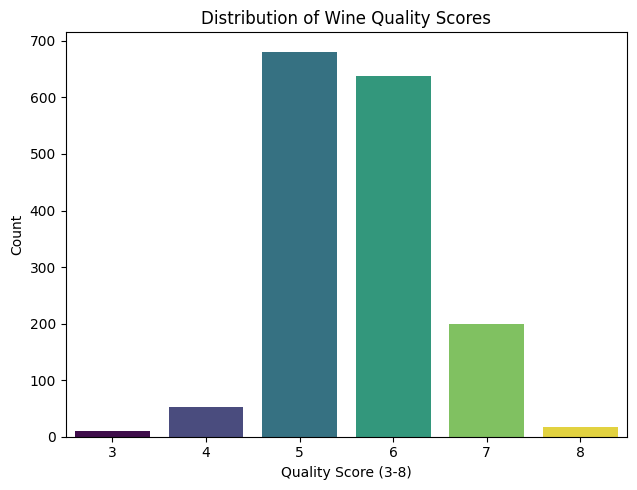

In [19]:
# --- Step 3: Exploratory Data Analysis (EDA) - Visualizations ---
# Set up a wider figure to hold three plots side-by-side
plt.figure(figsize=(18, 5))

# Plot 1: Bar chart of Quality Scores
plt.subplot(1, 3, 1)
# FIXED: Added hue='quality' and legend=False to resolve Seaborn warning
sns.countplot(data=df, x='quality', hue='quality', palette='viridis', legend=False)
plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score (3-8)")
plt.ylabel("Count")


plt.tight_layout()
plt.show()

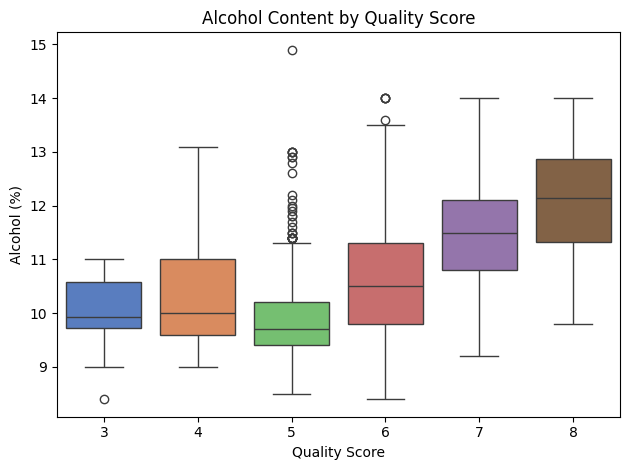

In [20]:

# FIXED: Added hue='quality' and legend=False to resolve Seaborn warning
sns.boxplot(data=df, x='quality', y='alcohol', hue='quality', palette='muted', legend=False)
plt.title("Alcohol Content by Quality Score")
plt.xlabel("Quality Score")
plt.ylabel("Alcohol (%)")
plt.tight_layout()
plt.show()

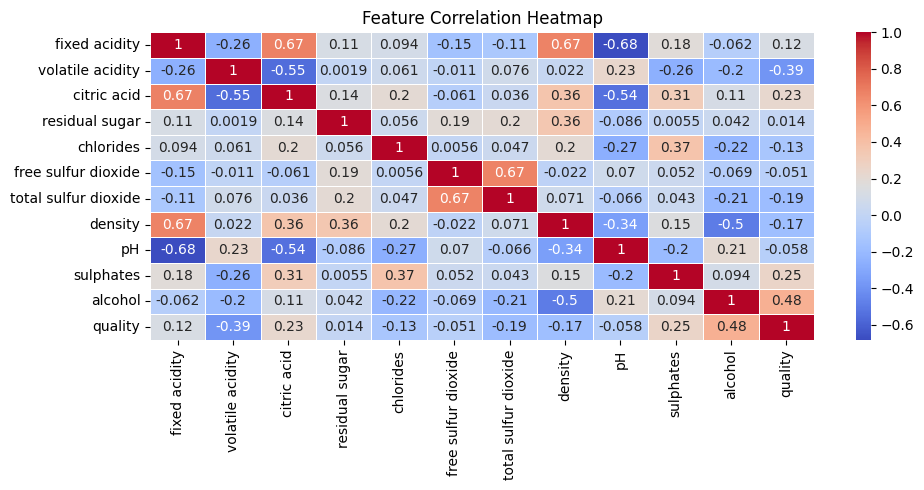

In [22]:

# FIXED: Added numeric_only=True to prevent ValueError on string columns like 'quality_class'
plt.figure(figsize=(10, 5))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")



plt.tight_layout()
plt.show()

In [6]:

# --- Step 2: Turn quality score (3-8) into 3 classes ---
def quality_to_class(q):
    if q <= 4:
        return 'low'
    elif q <= 6:
        return 'medium'
    else:
        return 'high'

df['quality_class'] = df['quality'].apply(quality_to_class)

X = df.drop(columns=['quality', 'quality_class'])
y = df['quality_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

--- Multinomial Logistic Regression ---
              precision    recall  f1-score   support

        high       0.34      0.72      0.47        43
         low       0.10      0.46      0.16        13
      medium       0.92      0.59      0.72       264

    accuracy                           0.61       320
   macro avg       0.46      0.59      0.45       320
weighted avg       0.81      0.61      0.67       320



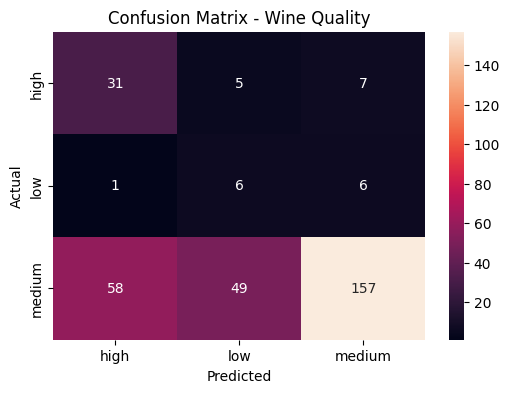

In [7]:
# --- Step 4: Train Multinomial Logistic Regression ---
# FIXED: Removed 'multi_class' parameter. It defaults to multinomial for 3+ classes.
model = LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("--- Multinomial Logistic Regression ---")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Wine Quality")
plt.show()

In [8]:
# --- Step 5: Compare with One-vs-Rest ---
# FIXED: Wrapped in OneVsRestClassifier instead of using multi_class='ovr'
base_model = LogisticRegression(solver='liblinear', max_iter=1000, class_weight='balanced')
model_ovr = OneVsRestClassifier(base_model)
model_ovr.fit(X_train_scaled, y_train)
y_pred_ovr = model_ovr.predict(X_test_scaled)

print("--- One-vs-Rest ---")
print(classification_report(y_test, y_pred_ovr))

--- One-vs-Rest ---
              precision    recall  f1-score   support

        high       0.32      0.67      0.44        43
         low       0.08      0.23      0.12        13
      medium       0.90      0.66      0.76       264

    accuracy                           0.64       320
   macro avg       0.43      0.52      0.44       320
weighted avg       0.79      0.64      0.69       320



In [9]:
# --- Step 6: Make a Manual Prediction on New Data ---
# Creating a dummy wine sample with 11 chemical features (must match X columns)
# Features: fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, 
# free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol
new_wine = np.array([[7.4, 0.70, 0.00, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]])

# 1. Scale the new data using the ALREADY FITTED scaler
new_wine_scaled = scaler.transform(new_wine)

# 2. Predict the class using the Multinomial model
manual_prediction = model.predict(new_wine_scaled)

# 3. View the underlying probabilities for each class
probabilities = model.predict_proba(new_wine_scaled)

print(f"Predicted Class: {manual_prediction[0]}")
print(f"Class Probabilities {model.classes_}: {probabilities[0]}")

Predicted Class: low
Class Probabilities ['high' 'low' 'medium']: [0.01381841 0.57123763 0.41494396]


d:\ANN_PTROJECT\penve\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
'''

Here's a line-by-line breakdown:

python
model = LogisticRegression(multi_class='multinomial', solver='lbfgs',
                            max_iter=1000, class_weight='balanced')
Creates a Logistic Regression model object (not trained yet).
multi_class='multinomial' → since you have 3 classes (low/medium/high), this tells sklearn to train one combined model that directly predicts probabilities across all classes at once (using the softmax function), instead of building 3 separate binary "one vs rest" classifiers. This usually gives better-calibrated probabilities for multiclass problems.
solver='lbfgs' → the optimization algorithm used to find the best coefficients. lbfgs is required (or one of a few options) when using multinomial — it's a solid general-purpose default.
max_iter=1000 → maximum number of iterations the solver is allowed to run while trying to converge on a solution. Default is 100, which is often too low and throws a "failed to converge" warning, so it's bumped up.
class_weight='balanced' → since your classes are likely imbalanced (medium quality wines are probably way more common than low/high), this automatically re-weights the loss function so the model doesn't just lazily predict "medium" every time. It penalizes mistakes on minority classes more heavily.
python
model.fit(X_train_scaled, y_train)
This is where actual training happens. The model looks at your scaled training features (X_train_scaled) and the true labels (y_train), and learns the coefficients that best separate the 3 classes.
python
y_pred = model.predict(X_test_scaled)
Uses the now-trained model to predict class labels (low/medium/high) for the test set it has never seen before. Output is an array of predicted class labels, same length as y_test.
python
print(classification_report(y_test, y_pred))
Compares true labels (y_test) vs predicted labels (y_pred) and prints a table showing precision, recall, f1-score, and support for each class individually, plus overall accuracy and macro/weighted averages. This tells you not just "how accurate" but where the model struggles (e.g., maybe it's great at "medium" but terrible at "low" since there's less data).
python
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
Builds a confusion matrix: a grid showing actual class (rows) vs predicted class (columns), with counts of how many predictions fell into each combination.
labels=model.classes_ ensures the rows/columns are ordered consistently according to how the model internally orders the classes (alphabetical: high, low, medium), so nothing gets mismatched.
python
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_)
Draws the confusion matrix as a color-coded heatmap using Seaborn, instead of just a plain grid of numbers — much easier to visually spot where the model confuses classes.
annot=True → shows the actual number in each cell.
fmt='d' → formats those numbers as integers (not scientific notation/decimals).
xticklabels / yticklabels → labels the axes with the actual class names (high/low/medium) instead of just 0/1/2.
python
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Wine Quality")
plt.show()
Standard matplotlib labeling: names the x-axis, y-axis, and chart title, then renders the plot on screen.
python
model_ovr = LogisticRegression(multi_class='ovr', solver='liblinear',
                                max_iter=1000, class_weight='balanced')
Creates a second model, this time using the One-vs-Rest (OvR) strategy instead of multinomial. This trains 3 separate binary classifiers under the hood (e.g., "low vs not-low", "medium vs not-medium", "high vs not-high") and picks whichever one is most confident for each prediction.
solver='liblinear' → a different optimizer, commonly paired with OvR (and required for some penalty types); works well on smaller datasets like this one.
python
model_ovr.fit(X_train_scaled, y_train)
Trains this second OvR model the same way as before.
python
y_pred_ovr = model_ovr.predict(X_test_scaled)
Generates predictions from the OvR model on the same test set, so you can directly compare it against the multinomial model's performance.
python
print("--- One-vs-Rest ---")
print(classification_report(y_test, y_pred_ovr))
Prints a header so the output is readable, then prints the same precision/recall/f1 report — but this time for the OvR model — so you can compare the two strategies side by side and see which one performs better on your specific dataset.'''